# Big Data Lab 6 - Incremental Updates: Snapshot + Changelog + Partition Recompute

So far in this course, you’ve mostly worked in a world where you can say: "here is the dataset" and process it once.

In real data engineering, that world lasts about five minutes.
Data arrives continuously, sometimes late, sometimes duplicated, sometimes missing for an hour, and your pipeline still has to be:
- correct,
- cheap enough to run every day,
- and explainable when someone asks "why did this number change?"

In this final lab you’ll build a **mini lakehouse-style workflow** using only **Google Colab + folders of Parquet files**. No Kafka, no cluster, no Delta/Iceberg/Hudi. Just the core ideas.

We’ll treat each GH Archive hour as a **micro-batch** and maintain two complementary artifacts:
- an append-only **changelog** (what each batch contributed), and
- a query-friendly **snapshot** (the latest state).

## What you'll build (end-to-end)
1. Download GH Archive hourly files as immutable **bronze** inputs.
2. Extract a stable **silver** events table, partitioned by `source_hour`.
3. For each hour, compute a **delta** table and append it to a **changelog**.
4. Maintain a latest **snapshot** partitioned by `day`, rewriting only affected partitions.
5. Prove **idempotency** by rerunning without producing duplicates.
6. Observe the **small files** problem and apply basic compaction.

## What you'll have at the end
Concrete artifacts on disk (this matters for grading and for your own debugging):
- `bronze_raw/<hour>.json.gz`
- `silver_events/source_hour=<hour>/part-00000.parquet`
- `delta_repo_day_changelog/batch_id=<id>/delta_<hour>.parquet`
- `snapshot_repo_day_metrics/day=<YYYY-MM-DD>/part-00000.parquet`
- `_state/checkpoint.json`

## Why this matters
This is the mental model behind modern incremental systems:
- **Changelog for truth/audit**: you can rebuild and explain changes.
- **Snapshot for speed**: analysts want fast queries on "current" data.
- **Partition recomputation**: Parquet is immutable; "updates" are rewrites of affected partitions.
- **State/checkpoints**: correctness depends on what you remember between runs.

## Evaluation
50% correctness/completion + 50% explanation.

Be ready to explain:
- snapshot vs changelog,
- what makes this pipeline idempotent,
- which partitions get recomputed and why,
- and which metrics are additive vs non-additive.


## Concepts cheat sheet (read once)

- **Changelog**: append-only record of per-batch deltas.
- **Snapshot**: latest state for fast analytics queries.
- **Idempotency**: rerunning the same batch does not duplicate results.
- **Checkpoint**: persisted state of processed input units.
- **Late data**: new records that modify old partitions.
- **Partition recompute**: update by rewriting immutable Parquet partitions.
- **Small files problem**: too many tiny files hurt scan performance.


## Setup (run once)


In [1]:
!pip -q install duckdb pyarrow matplotlib


## Optional: Persist outputs in Google Drive


In [2]:
from pathlib import Path
import glob
import json
import shutil
import subprocess
import time
import uuid
from dataclasses import dataclass

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

from google.colab import drive  # type: ignore

USE_DRIVE = False  # change to True to persist outputs

if USE_DRIVE:
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/BDLab/Lab6_Incremental')
else:
    BASE_DIR = Path('/content/BDLab/Lab6_Incremental')

BRONZE_DIR = BASE_DIR / 'bronze_raw'
SILVER_DIR = BASE_DIR / 'silver_events'
DELTA_DIR = BASE_DIR / 'delta_repo_day_changelog'
SNAPSHOT_DIR = BASE_DIR / 'snapshot_repo_day_metrics'
COMPACTED_DELTA_DIR = BASE_DIR / 'delta_compacted'
STATE_DIR = BASE_DIR / '_state'
CHECKPOINT_PATH = STATE_DIR / 'checkpoint.json'

for d in [BRONZE_DIR, SILVER_DIR, DELTA_DIR, SNAPSHOT_DIR, COMPACTED_DELTA_DIR, STATE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

BASE_DIR


PosixPath('/content/BDLab/Lab6_Incremental')

## 1) Ingest bronze: define micro-batches and download hourly files

Each GH Archive hour acts as one micro-batch input unit.


In [3]:
DATE_PREFIX = '2024-01-15'
HOURS = [12, 13, 14]
HOUR_KEYS = [f"{DATE_PREFIX}-{h}" for h in HOURS]

BATCHES = [
    {'batch_id': 'b1', 'hours': [HOUR_KEYS[0]]},
    {'batch_id': 'b2', 'hours': [HOUR_KEYS[1]]},
    {'batch_id': 'b3', 'hours': [HOUR_KEYS[2]]},
]


def gharchive_url(hour_key: str) -> str:
    return f"https://data.gharchive.org/{hour_key}.json.gz"


def bronze_path(hour_key: str) -> Path:
    return BRONZE_DIR / f"{hour_key}.json.gz"


def download_if_missing(hour_key: str) -> Path:
    out = bronze_path(hour_key)
    if out.exists() and out.stat().st_size > 0:
        print(f"Already present: {out.name} ({out.stat().st_size/1024/1024:.1f} MB)")
        return out

    url = gharchive_url(hour_key)
    attempts = [
        ('wget', ['wget', '-q', '--tries=3', '--retry-connrefused', '--waitretry=2', '-O', str(out), url]),
        ('curl', ['curl', '-fsSL', '--retry', '3', '--retry-delay', '2', '-o', str(out), url]),
    ]

    last_err = None
    for tool_name, cmd in attempts:
        try:
            print(f"Downloading {url} via {tool_name}...")
            subprocess.run(cmd, check=True)
            if out.exists() and out.stat().st_size > 0:
                print(f"Saved: {out.name} ({out.stat().st_size/1024/1024:.1f} MB)")
                return out
        except subprocess.CalledProcessError as e:
            last_err = e
            print(f"{tool_name} failed for {hour_key}: exit={e.returncode}")
        finally:
            if out.exists() and out.stat().st_size == 0:
                out.unlink(missing_ok=True)

    raise RuntimeError(
        f"Download failed for {hour_key}. This hour may be temporarily unavailable on GH Archive. "
        f"Try a nearby hour (e.g., 2024-01-14-23 or 2024-01-15-12)."
    ) from last_err


for hk in HOUR_KEYS:
    download_if_missing(hk)

pd.DataFrame({
    'source_hour': HOUR_KEYS,
    'file_mb': [bronze_path(hk).stat().st_size / 1024 / 1024 for hk in HOUR_KEYS],
}).sort_values('source_hour')


Saved: 2024-01-15-12.json.gz (117.6 MB)
Saved: 2024-01-15-13.json.gz (125.0 MB)
Saved: 2024-01-15-14.json.gz (131.4 MB)


,source_hour,file_mb
0,2024-01-15-12,117.566851
1,2024-01-15-13,124.999067
2,2024-01-15-14,131.385324


### Tiny exercise 1 (5-10 minutes)

Modify `BATCHES` to simulate a realistic arrival pattern (for example, two hours together and one late hour).

Answer briefly:
- Which `day=` snapshot partitions should be recomputed?
- Why only those partitions?


In [ ]:
# Tiny exercise 1
# TODO: adjust BATCHES and write 2-3 sentences with your reasoning.


## 2) Inspect raw data safely

Inspect event distribution without loading everything into memory.


In [4]:
con = duckdb.connect(database=':memory:')

sample_hour = HOUR_KEYS[0]
raw = bronze_path(sample_hour).as_posix()

event_mix = con.execute(f"""
SELECT
  CAST(type AS VARCHAR) AS event_type,
  COUNT(*) AS rows
FROM read_json_auto('{raw}', format='newline_delimited', ignore_errors=true)
GROUP BY 1
ORDER BY rows DESC
LIMIT 12
""").df()

event_mix


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_type,rows
0,PushEvent,200257
1,CreateEvent,26381
2,PullRequestEvent,15886
3,IssueCommentEvent,10144
4,WatchEvent,8669
5,DeleteEvent,6747
6,PullRequestReviewEvent,5996
7,IssuesEvent,3666
8,PullRequestReviewCommentEvent,3482
9,ForkEvent,2083


## 3) Output layout + checkpoint helpers

Rule: mark an hour as processed only after silver and delta writes succeed.


In [5]:
def load_checkpoint(path: Path):
    if not path.exists():
        return {'processed_hours': [], 'runs': []}
    return json.loads(path.read_text(encoding='utf-8'))


def save_checkpoint(path: Path, ckpt: dict):
    path.write_text(json.dumps(ckpt, indent=2, sort_keys=True), encoding='utf-8')


def write_partition_atomic(base_dir: Path, partition_key: str, partition_value: str, table: pa.Table):
    final_dir = base_dir / f"{partition_key}={partition_value}"
    tmp_dir = base_dir / f".tmp_{partition_key}={partition_value}_{uuid.uuid4().hex}"
    bak_dir = base_dir / f".bak_{partition_key}={partition_value}_{uuid.uuid4().hex}"

    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)

    pq.write_table(table, tmp_dir / 'part-00000.parquet', compression='snappy')
    (tmp_dir / '_SUCCESS').write_text('', encoding='utf-8')

    if final_dir.exists():
        if bak_dir.exists():
            shutil.rmtree(bak_dir)
        final_dir.rename(bak_dir)

    tmp_dir.rename(final_dir)

    if bak_dir.exists():
        shutil.rmtree(bak_dir)

    return final_dir


## 4) Silver extraction + per-hour delta computation

Silver contract columns:
- `event_id`, `event_type`, `created_at_ts`, `repo_name`, `actor_login`, `source_hour`


In [6]:
ALLOWED_EVENT_TYPES = [
    'PushEvent',
    'PullRequestEvent',
    'PullRequestReviewEvent',
    'PullRequestReviewCommentEvent',
    'IssuesEvent',
    'IssueCommentEvent',
    'CreateEvent',
    'DeleteEvent',
    'ForkEvent',
    'ReleaseEvent',
]

EXCLUDE_BOTS = True
ALLOWED_TYPES_SQL = ', '.join([f"'{t}'" for t in ALLOWED_EVENT_TYPES])

CORE_INVALID_PRED = "(event_id IS NULL OR event_id='' OR event_type IS NULL OR created_at_ts IS NULL OR repo_name IS NULL OR actor_login IS NULL OR actor_login='')"
BOT_PRED = "actor_login ILIKE '%[bot]'" if EXCLUDE_BOTS else "FALSE"
EXCLUDED_TYPE_PRED = f"(event_type NOT IN ({ALLOWED_TYPES_SQL}))"
INVALID_PRED = f"({CORE_INVALID_PRED} OR ({BOT_PRED}) OR {EXCLUDED_TYPE_PRED})"
KEEP_PRED = f"NOT ({INVALID_PRED})"


def raw_sql(hour_key: str) -> str:
    raw = bronze_path(hour_key).as_posix()
    return f"""
    SELECT
      CAST(id AS VARCHAR) AS event_id,
      CAST(type AS VARCHAR) AS event_type,
      TRY_CAST(created_at AS TIMESTAMP) AS created_at_ts,
      CAST(repo.name AS VARCHAR) AS repo_name,
      CAST(actor.login AS VARCHAR) AS actor_login,
      '{hour_key}'::VARCHAR AS source_hour
    FROM read_json_auto('{raw}', format='newline_delimited', ignore_errors=true)
    """


def materialize_raw_hour(hour_key: str):
    con.execute('DROP TABLE IF EXISTS raw_hour')
    con.execute(f"CREATE TEMP TABLE raw_hour AS {raw_sql(hour_key)}")


def extract_silver_hour(hour_key: str) -> pa.Table:
    return con.execute(f"""
    SELECT
      event_id,
      event_type,
      created_at_ts,
      repo_name,
      actor_login,
      source_hour
    FROM raw_hour
    WHERE {KEEP_PRED}
    """).arrow()


def delta_path(batch_id: str, hour_key: str) -> Path:
    out_dir = DELTA_DIR / f"batch_id={batch_id}"
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir / f"delta_{hour_key}.parquet"


def compute_delta_for_hour(batch_id: str, hour_key: str) -> pa.Table:
    return con.execute(f"""
    SELECT
      CAST(date_trunc('day', created_at_ts) AS DATE) AS day,
      repo_name,
      COUNT(*) AS events_total,
      SUM(CASE WHEN event_type='PushEvent' THEN 1 ELSE 0 END) AS push_events,
      SUM(CASE WHEN event_type='PullRequestEvent' THEN 1 ELSE 0 END) AS pr_events,
      '{hour_key}'::VARCHAR AS source_hour,
      '{batch_id}'::VARCHAR AS batch_id
    FROM raw_hour
    WHERE {KEEP_PRED}
    GROUP BY 1,2
    """).arrow()


def write_delta(batch_id: str, hour_key: str, table: pa.Table) -> Path:
    out = delta_path(batch_id, hour_key)
    pq.write_table(table, out, compression='snappy')
    return out


## 5) Snapshot recompute for affected day partitions

We aggregate additive metrics from changelog and recompute a non-additive metric (`unique_actors`) from silver.


In [7]:
def ensure_parquet_files(glob_pat: str, name: str):
    files = sorted(glob.glob(glob_pat))
    if not files:
        raise FileNotFoundError(f"No Parquet files found for {name}: {glob_pat}")
    return files


def recompute_snapshot_for_day(day_value: str) -> Path:
    delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()
    silver_glob = (SILVER_DIR / 'source_hour=*' / '*.parquet').as_posix()

    ensure_parquet_files(delta_glob, 'delta changelog')
    ensure_parquet_files(silver_glob, 'silver events')

    result = con.execute(f"""
    WITH d AS (
      SELECT
        day,
        repo_name,
        SUM(events_total) AS events_total,
        SUM(push_events) AS push_events,
        SUM(pr_events) AS pr_events
      FROM read_parquet('{delta_glob}')
      WHERE day = CAST('{day_value}' AS DATE)
      GROUP BY 1,2
    ),
    a AS (
      SELECT
        CAST(date_trunc('day', created_at_ts) AS DATE) AS day,
        repo_name,
        COUNT(DISTINCT actor_login) AS unique_actors
      FROM read_parquet('{silver_glob}')
      WHERE CAST(date_trunc('day', created_at_ts) AS DATE) = CAST('{day_value}' AS DATE)
      GROUP BY 1,2
    )
    SELECT
      d.day,
      d.repo_name,
      d.events_total,
      d.push_events,
      d.pr_events,
      COALESCE(a.unique_actors, 0) AS unique_actors,
      NOW() AS snapshot_updated_at
    FROM d
    LEFT JOIN a
      ON d.day = a.day AND d.repo_name = a.repo_name
    ORDER BY d.events_total DESC, d.repo_name
    """).arrow()

    return write_partition_atomic(SNAPSHOT_DIR, 'day', day_value, result)


## 6) Incremental runner (checkpointed, idempotent)


In [8]:
@dataclass
class RunConfig:
    run_id: str
    force_recompute_hours: set[str] | None = None


def run_incremental(cfg: RunConfig, batches: list[dict]) -> pd.DataFrame:
    ckpt = load_checkpoint(CHECKPOINT_PATH)
    processed = set(ckpt.get('processed_hours', []))
    force = cfg.force_recompute_hours or set()

    logs = []

    for batch in batches:
        batch_id = batch['batch_id']
        hours = batch['hours']
        affected_days: set[str] = set()

        print(f"\n=== Batch {batch_id} ({len(hours)} hour(s)) ===")

        for hk in hours:
            if hk in processed and hk not in force:
                print(f"SKIP {hk} (checkpoint)")
                continue

            print(f"PROCESS {hk}")
            t0 = time.perf_counter()

            download_if_missing(hk)
            materialize_raw_hour(hk)

            silver_tbl = extract_silver_hour(hk)
            write_partition_atomic(SILVER_DIR, 'source_hour', hk, silver_tbl)

            delta_tbl = compute_delta_for_hour(batch_id, hk)
            delta_out = write_delta(batch_id, hk, delta_tbl)

            day_values = [str(d) for d in set(delta_tbl.column('day').to_pylist()) if d is not None]
            for d in day_values:
                affected_days.add(d)

            t1 = time.perf_counter()
            logs.append({
                'run_id': cfg.run_id,
                'batch_id': batch_id,
                'source_hour': hk,
                'silver_rows': int(silver_tbl.num_rows),
                'delta_rows': int(delta_tbl.num_rows),
                'delta_path': str(delta_out),
                'total_s': t1 - t0,
            })

            if hk not in processed:
                ckpt['processed_hours'] = sorted(set(ckpt['processed_hours'] + [hk]))
                processed.add(hk)
            save_checkpoint(CHECKPOINT_PATH, ckpt)

        for day_value in sorted(affected_days):
            print(f"RECOMPUTE snapshot day={day_value}")
            recompute_snapshot_for_day(day_value)

    ckpt.setdefault('runs', []).append({'run_id': cfg.run_id, 'ts': time.time(), 'rows_logged': len(logs)})
    save_checkpoint(CHECKPOINT_PATH, ckpt)

    return pd.DataFrame(logs)


## 7) Main run


In [9]:
run1 = run_incremental(RunConfig(run_id='run1'), BATCHES)
run1



=== Batch b1 (1 hour(s)) ===
PROCESS 2024-01-15-12
Already present: 2024-01-15-12.json.gz (117.6 MB)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RECOMPUTE snapshot day=2024-01-15

=== Batch b2 (1 hour(s)) ===
PROCESS 2024-01-15-13
Already present: 2024-01-15-13.json.gz (125.0 MB)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RECOMPUTE snapshot day=2024-01-15

=== Batch b3 (1 hour(s)) ===
PROCESS 2024-01-15-14
Already present: 2024-01-15-14.json.gz (131.4 MB)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RECOMPUTE snapshot day=2024-01-15


,run_id,batch_id,source_hour,silver_rows,delta_rows,delta_path,total_s
0,run1,b1,2024-01-15-12,192520,53596,/content/BDLab/Lab6_Incremental/delta_repo_day...,5.743977
1,run1,b2,2024-01-15-13,207466,58435,/content/BDLab/Lab6_Incremental/delta_repo_day...,4.989197
2,run1,b3,2024-01-15-14,217636,62171,/content/BDLab/Lab6_Incremental/delta_repo_day...,6.499803


### Visual dashboard (optional)

This cell turns the "SKIP/PROCESS" logs into a quick visual status view:
- which hours exist on disk,
- which hours are checkpointed,
- and how many files/partitions you have per layer.


,hour,label,downloaded_bronze,silver_written,delta_written,checkpointed
0,2024-01-15-12,01-15 12,True,True,True,True
1,2024-01-15-13,01-15 13,True,True,True,True
2,2024-01-15-14,01-15 14,True,True,True,True


,layer,count
0,silver (files),3
1,delta changelog (files),3
2,snapshot (files),1


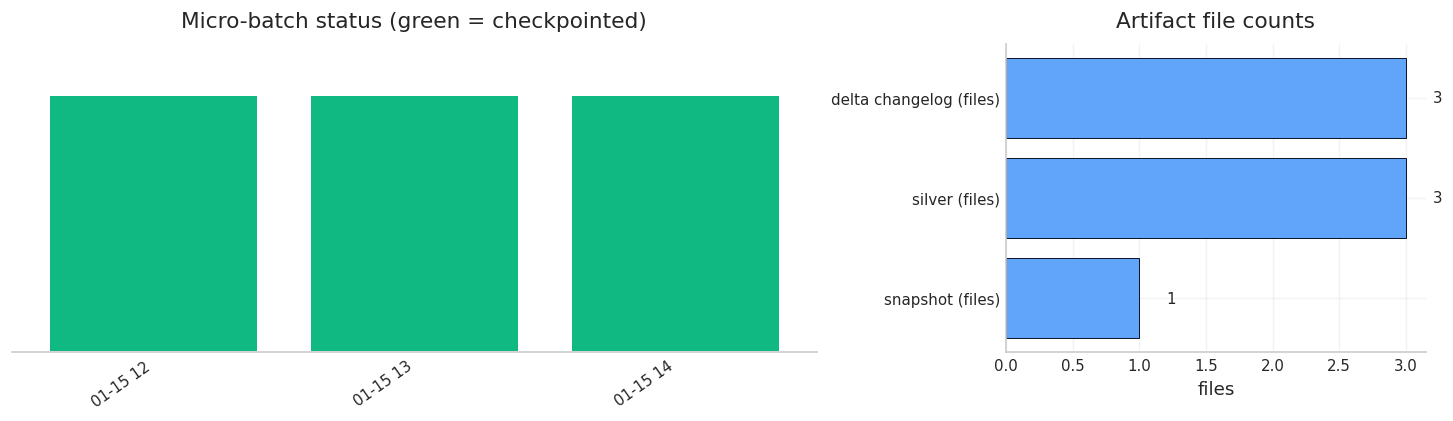

In [10]:
# Visual dashboard: checkpoint + artifacts (styled)

# A small style helper so plots look consistent and less "default".
def _apply_bd_style():
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except Exception:
        pass

    plt.rcParams.update({
        'figure.dpi': 120,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'axes.titlepad': 10,
        'grid.alpha': 0.25,
        'grid.linestyle': '-',
        'font.family': 'DejaVu Sans',
    })


_apply_bd_style()

ckpt = load_checkpoint(CHECKPOINT_PATH)
processed = set(ckpt.get('processed_hours', []))
expected = sorted({hk for b in BATCHES for hk in b['hours']})


def _short_hour(hk: str) -> str:
    parts = hk.split('-')
    # YYYY-MM-DD-HH -> MM-DD HH
    if len(parts) >= 4:
        return f"{parts[1]}-{parts[2]} {parts[3]}"
    return hk


status = []
for hk in expected:
    bronze_ok = bronze_path(hk).exists() and bronze_path(hk).stat().st_size > 0
    silver_ok = (SILVER_DIR / f"source_hour={hk}" / 'part-00000.parquet').exists()
    delta_ok = bool(glob.glob((DELTA_DIR / 'batch_id=*' / f"delta_{hk}.parquet").as_posix()))
    status.append({
        'hour': hk,
        'label': _short_hour(hk),
        'downloaded_bronze': bronze_ok,
        'silver_written': silver_ok,
        'delta_written': delta_ok,
        'checkpointed': hk in processed,
    })

status_df = pd.DataFrame(status)
display(status_df)

silver_files = sorted(glob.glob((SILVER_DIR / 'source_hour=*' / '*.parquet').as_posix()))
delta_files = sorted(glob.glob((DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()))
snapshot_files = sorted(glob.glob((SNAPSHOT_DIR / 'day=*' / '*.parquet').as_posix()))

inventory = pd.DataFrame([
    {'layer': 'silver (files)', 'count': len(silver_files)},
    {'layer': 'delta changelog (files)', 'count': len(delta_files)},
    {'layer': 'snapshot (files)', 'count': len(snapshot_files)},
])
display(inventory)

# --- Plots ---
if not status_df.empty:
    ok = status_df['checkpointed'].tolist()
    labels = status_df['label'].tolist()

    colors = ['#10b981' if v else '#ef4444' for v in ok]  # green/red

    fig, axes = plt.subplots(
        1, 2,
        figsize=(12, 3.4),
        constrained_layout=True,
        gridspec_kw={'width_ratios': [2.3, 1.2]},
    )

    # Timeline blocks
    ax = axes[0]
    ax.bar(range(len(labels)), [1] * len(labels), color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title('Micro-batch status (green = checkpointed)')
    ax.set_yticks([])
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.set_ylim(0, 1.2)
    ax.grid(False)
    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)

    # Inventory bars
    ax2 = axes[1]
    inv = inventory.sort_values('count')
    ax2.barh(inv['layer'], inv['count'], color='#60a5fa', edgecolor='#0f172a', linewidth=0.6)
    ax2.set_title('Artifact file counts')
    ax2.set_xlabel('files')
    ax2.grid(axis='x', alpha=0.25)

    max_cnt = max(inv['count'].max(), 1)
    for i, cnt in enumerate(inv['count'].tolist()):
        ax2.text(cnt + max(max_cnt * 0.02, 0.2), i, str(int(cnt)), va='center', fontsize=9)

    for spine in ['top', 'right']:
        ax2.spines[spine].set_visible(False)

    plt.show()


### Tiny exercise 2 (5-10 minutes)

Read `checkpoint.json` and explain what makes this idempotent.

Then propose one improvement:
- store source file size/hash per hour,
- and trigger reprocess if source content changes.


In [ ]:
# Tiny exercise 2
# TODO: inspect checkpoint and write your explanation.
# TODO: describe (or implement) a file-size/hash based reprocessing rule.

load_checkpoint(CHECKPOINT_PATH)


## 8) Rerun to prove idempotency


In [11]:
run2 = run_incremental(RunConfig(run_id='run2'), BATCHES)
run2



=== Batch b1 (1 hour(s)) ===
SKIP 2024-01-15-12 (checkpoint)

=== Batch b2 (1 hour(s)) ===
SKIP 2024-01-15-13 (checkpoint)

=== Batch b3 (1 hour(s)) ===
SKIP 2024-01-15-14 (checkpoint)


""


## 9) Late-arriving data: process one older hour

This simulates data for a previous day arriving after initial processing.
Only the impacted day partition should be recomputed.


In [12]:
LATE_BATCHES = [
    {'batch_id': 'b4_late', 'hours': ['2024-01-14-23']},
]

run3 = run_incremental(RunConfig(run_id='run3'), LATE_BATCHES)
run3



=== Batch b4_late (1 hour(s)) ===
PROCESS 2024-01-14-23
Saved: 2024-01-14-23.json.gz (50.1 MB)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

RECOMPUTE snapshot day=2024-01-14


,run_id,batch_id,source_hour,silver_rows,delta_rows,delta_path,total_s
0,run3,b4_late,2024-01-14-23,138681,30528,/content/BDLab/Lab6_Incremental/delta_repo_day...,4.316066


## 10) Query snapshot and changelog


In [13]:
snapshot_glob = (SNAPSHOT_DIR / 'day=*' / '*.parquet').as_posix()
delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()

ensure_parquet_files(snapshot_glob, 'snapshot')
ensure_parquet_files(delta_glob, 'delta')

print('Snapshot top rows')
display(con.execute(f"""
SELECT day, repo_name, events_total, push_events, pr_events, unique_actors
FROM read_parquet('{snapshot_glob}')
ORDER BY day DESC, events_total DESC
LIMIT 20
""").df())

print('Changelog coverage by batch/hour')
con.execute(f"""
SELECT batch_id, source_hour, COUNT(*) AS delta_rows
FROM read_parquet('{delta_glob}')
GROUP BY 1,2
ORDER BY source_hour, batch_id
""").df()


Snapshot top rows


,day,repo_name,events_total,push_events,pr_events,unique_actors
0,2024-01-15,LMAO-armv8/kernel_samsung_r0q,9644.0,9644.0,0.0,1
1,2024-01-15,oss333ulf/Projcts9,6551.0,6551.0,0.0,1
2,2024-01-15,inse2233tto/Projcts6,6506.0,6506.0,0.0,1
3,2024-01-15,ion561sdag/Projcts15,6502.0,6502.0,0.0,1
4,2024-01-15,inse2233tto/Projcts8,6495.0,6495.0,0.0,1
5,2024-01-15,ion561sdag/Projcts14,6487.0,6487.0,0.0,1
6,2024-01-15,ion561sdag/Projcts17,6484.0,6484.0,0.0,1
7,2024-01-15,inse2233tto/Projcts4,6483.0,6483.0,0.0,1
8,2024-01-15,inse2233tto/Projcts5,6478.0,6478.0,0.0,1
9,2024-01-15,inse2233tto/Projcts2,6476.0,6476.0,0.0,1


Changelog coverage by batch/hour


,batch_id,source_hour,delta_rows
0,b4_late,2024-01-14-23,30528
1,b1,2024-01-15-12,53596
2,b2,2024-01-15-13,58435
3,b3,2024-01-15-14,62171


### Visual: snapshot + changelog (optional)

These plots make the two core outputs tangible:
- snapshot: the latest state (fast to query)
- changelog: what each batch contributed (great for audit/rebuild)


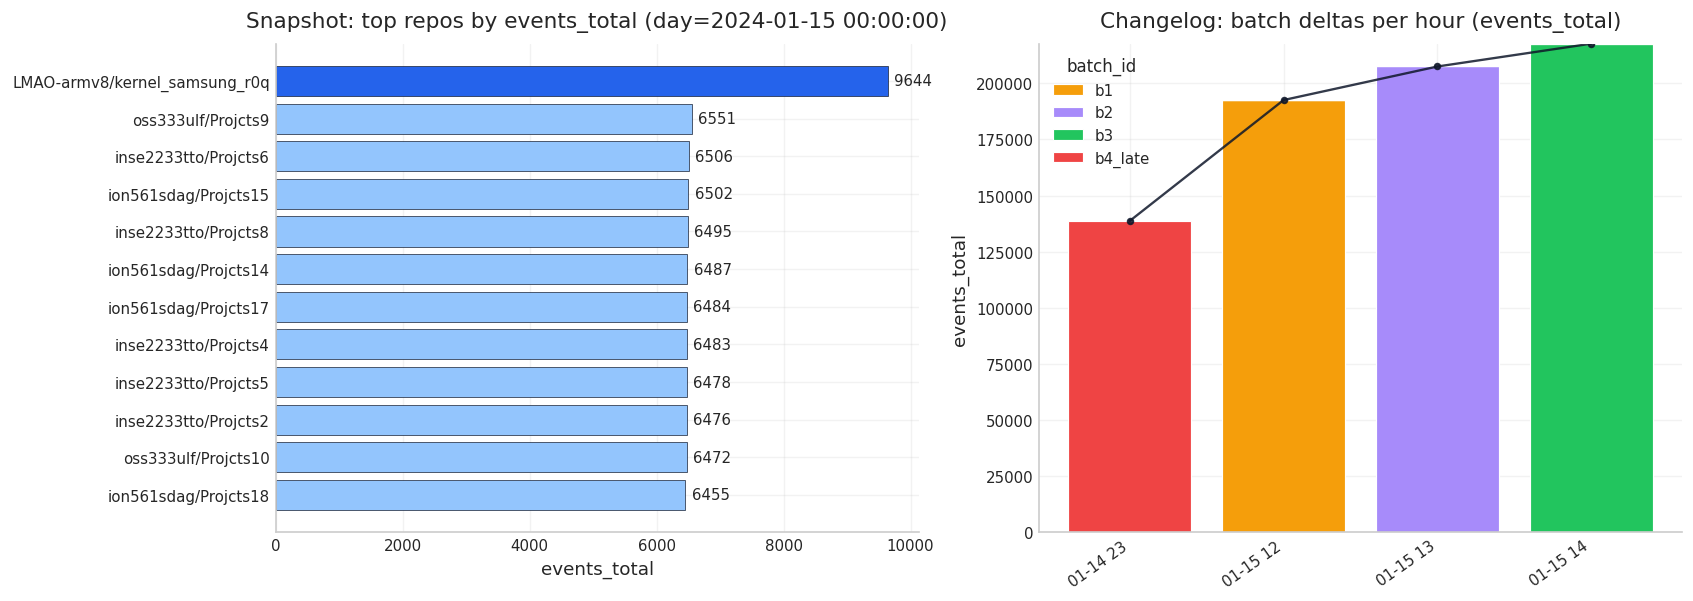

In [14]:
# Visual: snapshot + changelog (styled)

# Keep this cell runnable even if you didn't run the dashboard cell.
def _apply_bd_style():
    try:
        plt.style.use('seaborn-v0_8-whitegrid')
    except Exception:
        pass

    plt.rcParams.update({
        'figure.dpi': 120,
        'axes.titlesize': 13,
        'axes.labelsize': 11,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'axes.titlepad': 10,
        'grid.alpha': 0.25,
        'grid.linestyle': '-',
        'font.family': 'DejaVu Sans',
    })


_apply_bd_style()

snapshot_glob = (SNAPSHOT_DIR / 'day=*' / '*.parquet').as_posix()
delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()

ensure_parquet_files(snapshot_glob, 'snapshot')
ensure_parquet_files(delta_glob, 'delta')

snap_df = con.execute(f"""
SELECT
  CAST(day AS DATE) AS day,
  repo_name,
  events_total,
  push_events,
  pr_events,
  unique_actors
FROM read_parquet('{snapshot_glob}')
""").df()

chg_df = con.execute(f"""
SELECT
  batch_id,
  source_hour,
  SUM(events_total) AS events_total
FROM read_parquet('{delta_glob}')
GROUP BY 1,2
""").df()

if snap_df.empty:
    print('Snapshot is empty (nothing processed yet).')
else:
    latest_day = snap_df['day'].max()
    top = (
        snap_df[snap_df['day'] == latest_day]
        .nlargest(12, 'events_total')
        .sort_values('events_total')
        .copy()
    )

    def _short_repo(s: str, n: int = 38) -> str:
        if s is None:
            return ''
        return s if len(s) <= n else ('...' + s[-(n-3):])

    top['repo_short'] = top['repo_name'].map(_short_repo)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.9), constrained_layout=True)

    # Snapshot barh with value labels
    ax = axes[0]
    vals = top['events_total'].astype(float).tolist()

    vmin = float(top['events_total'].min())
    vmax = float(top['events_total'].max())
    denom = (vmax - vmin) if vmax != vmin else 1.0

    shades = [((v - vmin) / denom) for v in vals]
    colors = ['#93c5fd' if s < 0.33 else ('#60a5fa' if s < 0.66 else '#2563eb') for s in shades]

    ax.barh(top['repo_short'], vals, color=colors, edgecolor='#0f172a', linewidth=0.4)
    ax.set_title(f"Snapshot: top repos by events_total (day={latest_day})")
    ax.set_xlabel('events_total')
    ax.grid(axis='x', alpha=0.25)

    pad = max(max(vals) * 0.01, 0.5)
    for i, v in enumerate(vals):
        ax.text(v + pad, i, str(int(v)), va='center', fontsize=9)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

    # Changelog stacked bars + total line
    ax2 = axes[1]
    if chg_df.empty:
        ax2.set_title('Changelog: no deltas yet')
        ax2.axis('off')
    else:
        def _short_hour(hk: str) -> str:
            parts = hk.split('-')
            if len(parts) >= 4:
                return f"{parts[1]}-{parts[2]} {parts[3]}"
            return hk

        chg_df = chg_df.copy()
        chg_df['label'] = chg_df['source_hour'].map(_short_hour)
        pivot = (
            chg_df
            .pivot_table(index='label', columns='batch_id', values='events_total', aggfunc='sum', fill_value=0)
            .sort_index()
        )

        palette = ['#f59e0b', '#a78bfa', '#22c55e', '#ef4444', '#06b6d4', '#64748b']
        colors = {b: palette[i % len(palette)] for i, b in enumerate(pivot.columns)}

        bottom = None
        x = list(range(len(pivot.index)))
        for col in pivot.columns:
            y = pivot[col].values
            ax2.bar(x, y, bottom=bottom, label=col, color=colors[col], edgecolor='white', linewidth=0.7)
            bottom = y if bottom is None else (bottom + y)

        totals = pivot.sum(axis=1).values
        ax2.plot(x, totals, color='#0f172a', linewidth=1.4, marker='o', markersize=3.5, alpha=0.85)

        ax2.set_title('Changelog: batch deltas per hour (events_total)')
        ax2.set_xticks(x)
        ax2.set_xticklabels(list(pivot.index), rotation=35, ha='right')
        ax2.set_ylabel('events_total')
        ax2.grid(axis='y', alpha=0.25)
        ax2.legend(title='batch_id', frameon=False, loc='upper left')

        for spine in ['top', 'right']:
            ax2.spines[spine].set_visible(False)

    plt.show()


## 11) Small files and compaction helper

Compaction merges many small delta files into one partition file.


In [17]:
def compact_delta_for_day(day_value: str) -> Path:
    delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()
    ensure_parquet_files(delta_glob, 'delta')

    compact_tbl = con.execute(f"""
    SELECT
      day,
      repo_name,
      SUM(events_total) AS events_total,
      SUM(push_events) AS push_events,
      SUM(pr_events) AS pr_events
    FROM read_parquet('{delta_glob}')
    WHERE day = CAST('{day_value}' AS DATE)
    GROUP BY 1,2
    ORDER BY events_total DESC
    """).arrow()

    return write_partition_atomic(COMPACTED_DELTA_DIR, 'day', day_value, compact_tbl)


all_delta_files = sorted(glob.glob((DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()))
print('delta files:', len(all_delta_files))
all_delta_files[:6]


delta files: 4


['/content/BDLab/Lab6_Incremental/delta_repo_day_changelog/batch_id=b1/delta_2024-01-15-12.parquet',
 '/content/BDLab/Lab6_Incremental/delta_repo_day_changelog/batch_id=b2/delta_2024-01-15-13.parquet',
 '/content/BDLab/Lab6_Incremental/delta_repo_day_changelog/batch_id=b3/delta_2024-01-15-14.parquet',
 '/content/BDLab/Lab6_Incremental/delta_repo_day_changelog/batch_id=b4_late/delta_2024-01-14-23.parquet']

### Tiny exercise 3 (10 minutes)

Use `compact_delta_for_day(day)` for one day and explain:
- why compaction helps,
- and one scenario where compaction hurts.


In [ ]:
# Tiny exercise 3
# TODO: choose a day and run compaction.
# Example: compact_delta_for_day('2024-01-15')


# Mini-assignment (end of lab)

## Assignment A - Extend to 2 days
Process data covering two days and prove that only impacted `day=` snapshot partitions are rewritten.

Required evidence:
- snapshot has both day partitions,
- logs show which partition was recomputed per new batch.

## Assignment B - Rebuild snapshot from changelog
Write `rebuild_snapshot_from_changelog()` that deletes and recreates snapshot partitions only from the delta changelog.

Explain:
- why changelog enables deterministic rebuild,
- what minimum fields changelog must contain.

## Assignment C - Oral prompts
Prepare short answers:
- Snapshot vs changelog: which one do you query and why?
- Why can we not update rows inside Parquet directly?
- Give one additive and one non-additive metric from this lab.
- Name one bug that would break idempotency.


In [20]:
# Assignment A + B solution

# -----------------------------
# Assignment A - Extend to 2 days
# -----------------------------
# We use one hour from 2024-01-14 and two hours from 2024-01-15.
# This lets us prove that only impacted day partitions are recomputed.

TWO_DAY_BATCHES = [
    {'batch_id': 'a1_day1', 'hours': ['2024-01-14-23']},
    {'batch_id': 'a2_day2', 'hours': ['2024-01-15-12']},
    {'batch_id': 'a3_day2', 'hours': ['2024-01-15-13']},
]


def hour_key_to_day(hour_key: str) -> str:
    return str(pd.to_datetime(hour_key, format='%Y-%m-%d-%H').date())


def assignment_a_expected_partition_rewrites(batches: list[dict]) -> pd.DataFrame:
    rows = []
    for b in batches:
        impacted_days = sorted({hour_key_to_day(hk) for hk in b['hours']})
        rows.append({
            'batch_id': b['batch_id'],
            'hours': ', '.join(b['hours']),
            'expected_recomputed_snapshot_partitions': ', '.join([f"day={d}" for d in impacted_days]),
        })
    return pd.DataFrame(rows)


# Optional helper to start Assignment A from a clean state in this runtime.
# Do not run this if you want to preserve current artifacts.
def reset_incremental_artifacts_for_assignment_a():
    for d in [SILVER_DIR, DELTA_DIR, SNAPSHOT_DIR, COMPACTED_DELTA_DIR]:
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)
    save_checkpoint(CHECKPOINT_PATH, {'processed_hours': [], 'runs': []})


# Suggested execution sequence (intentionally not executed here):
# reset_incremental_artifacts_for_assignment_a()
# run_a = run_incremental(RunConfig(run_id='assignment_a_run'), TWO_DAY_BATCHES)
#
# Evidence 1: expected day partitions recomputed by each batch
assignment_a_expected_partition_rewrites(TWO_DAY_BATCHES)
#
# Evidence 2: snapshot has both day partitions
con.execute(f"""
SELECT DISTINCT day
FROM read_parquet('{(SNAPSHOT_DIR / 'day=*' / '*.parquet').as_posix()}')
ORDER BY day
""").df()
#
# Evidence 3: changelog shows processed batches/hours
con.execute(f"""
SELECT batch_id, source_hour, COUNT(*) AS rows_written
FROM read_parquet('{(DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()}')
GROUP BY 1, 2
ORDER BY source_hour, batch_id
""").df()


# -----------------------------
# Assignment B - Rebuild snapshot from changelog only
# -----------------------------
# Note: current changelog stores additive metrics only.
# Therefore, unique_actors cannot be exactly reconstructed from changelog as currently designed.
# We set unique_actors=NULL in this rebuild and explain required minimum fields below.

def rebuild_snapshot_from_changelog() -> pd.DataFrame:
    delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()
    ensure_parquet_files(delta_glob, 'delta changelog')

    days = con.execute(f"""
    SELECT DISTINCT CAST(day AS VARCHAR) AS day
    FROM read_parquet('{delta_glob}')
    ORDER BY day
    """).df()['day'].tolist()

    # Remove old snapshot day partitions, then recreate deterministically from changelog.
    for p in SNAPSHOT_DIR.glob('day=*'):
        if p.is_dir():
            shutil.rmtree(p)

    rebuilt_rows = []

    for day_value in days:
        tbl = con.execute(f"""
        SELECT
          day,
          repo_name,
          SUM(events_total) AS events_total,
          SUM(push_events) AS push_events,
          SUM(pr_events) AS pr_events,
          CAST(NULL AS BIGINT) AS unique_actors,
          NOW() AS snapshot_updated_at
        FROM read_parquet('{delta_glob}')
        WHERE day = CAST('{day_value}' AS DATE)
        GROUP BY 1,2
        ORDER BY events_total DESC, repo_name
        """).arrow()

        out = write_partition_atomic(SNAPSHOT_DIR, 'day', day_value, tbl)
        rebuilt_rows.append({'day': day_value, 'rows': int(tbl.num_rows), 'path': str(out)})

    return pd.DataFrame(rebuilt_rows)


MIN_CHANGELOG_FIELDS_FOR_DETERMINISTIC_REBUILD = [
    'day',
    'repo_name',
    'events_total',
    'push_events',
    'pr_events',
    # Plus actor-level lineage (for example actor_login per event/repo/day) if unique_actors must be exact.
]

ASSIGNMENT_B_EXPLANATION = """
Changelog enables deterministic rebuild because it is append-only and captures each batch contribution with stable keys.
If the same changelog files are replayed with the same aggregation logic, snapshot output is reproducible.
Minimum fields are partition key (day), business key (repo_name), and all additive contributions required by snapshot metrics.
For exact non-additive metrics like unique_actors, changelog must also include actor-level detail (or another sketch/state that supports exact/approx distinct recomputation).
""".strip()

# Optional run for Assignment B evidence (not executed):
rebuilt = rebuild_snapshot_from_changelog()
rebuilt
print(ASSIGNMENT_B_EXPLANATION)
MIN_CHANGELOG_FIELDS_FOR_DETERMINISTIC_REBUILD

Changelog enables deterministic rebuild because it is append-only and captures each batch contribution with stable keys.
If the same changelog files are replayed with the same aggregation logic, snapshot output is reproducible.
Minimum fields are partition key (day), business key (repo_name), and all additive contributions required by snapshot metrics.
For exact non-additive metrics like unique_actors, changelog must also include actor-level detail (or another sketch/state that supports exact/approx distinct recomputation).


['day', 'repo_name', 'events_total', 'push_events', 'pr_events']

In [22]:
# Assignment A execution cell (explicit run + evidence)
# Run this cell after the Assignment A+B definition cell above.

RUN_ASSIGNMENT_A = True
RESET_BEFORE_ASSIGNMENT_A = False

if RESET_BEFORE_ASSIGNMENT_A:
    for d in [SILVER_DIR, DELTA_DIR, SNAPSHOT_DIR, COMPACTED_DELTA_DIR]:
        if d.exists():
            shutil.rmtree(d)
        d.mkdir(parents=True, exist_ok=True)
    save_checkpoint(CHECKPOINT_PATH, {'processed_hours': [], 'runs': []})

if RUN_ASSIGNMENT_A:
    print('Assignment A expected impacted day partitions by batch:')
    display(assignment_a_expected_partition_rewrites(TWO_DAY_BATCHES))

    run_a = run_incremental(RunConfig(run_id='assignment_a_run'), TWO_DAY_BATCHES)


    snapshot_glob = (SNAPSHOT_DIR / 'day=*' / '*.parquet').as_posix()
    delta_glob = (DELTA_DIR / 'batch_id=*' / '*.parquet').as_posix()

    print('\nAssignment A evidence: snapshot has both day partitions:')
    display(con.execute(f"""
    SELECT DISTINCT day
    FROM read_parquet('{snapshot_glob}')
    ORDER BY day
    """).df())

    print('\nAssignment A evidence: changelog coverage by batch/hour:')
    display(con.execute(f"""
    SELECT batch_id, source_hour, COUNT(*) AS rows_written
    FROM read_parquet('{delta_glob}')
    GROUP BY 1, 2
    ORDER BY source_hour, batch_id
    """).df())

    print('\nAssignment A evidence: impacted day partitions per batch (from changelog):')
    display(con.execute(f"""
    SELECT batch_id, day, SUM(events_total) AS events_total
    FROM read_parquet('{delta_glob}')
    GROUP BY 1, 2
    ORDER BY batch_id, day
    """).df())

Assignment A expected impacted day partitions by batch:


,batch_id,hours,expected_recomputed_snapshot_partitions
0,a1_day1,2024-01-14-23,day=2024-01-14
1,a2_day2,2024-01-15-12,day=2024-01-15
2,a3_day2,2024-01-15-13,day=2024-01-15



=== Batch a1_day1 (1 hour(s)) ===
SKIP 2024-01-14-23 (checkpoint)

=== Batch a2_day2 (1 hour(s)) ===
SKIP 2024-01-15-12 (checkpoint)

=== Batch a3_day2 (1 hour(s)) ===
SKIP 2024-01-15-13 (checkpoint)

Assignment A evidence: snapshot has both day partitions:


,day
0,2024-01-14
1,2024-01-15



Assignment A evidence: changelog coverage by batch/hour:


,batch_id,source_hour,rows_written
0,b4_late,2024-01-14-23,30528
1,b1,2024-01-15-12,53596
2,b2,2024-01-15-13,58435
3,b3,2024-01-15-14,62171



Assignment A evidence: impacted day partitions per batch (from changelog):


,batch_id,day,events_total
0,b1,2024-01-15,192520.0
1,b2,2024-01-15,207466.0
2,b3,2024-01-15,217636.0
3,b4_late,2024-01-14,138681.0


## Assignment C - Oral prompts (prepared answers)

1. **Snapshot vs changelog: which one do you query and why?**
I query the snapshot for day-to-day analytics because it is pre-aggregated and fast. I query the changelog for audit/debug/rebuild tasks because it records what each batch contributed.

2. **Why can we not update rows inside Parquet directly?**
Parquet files are immutable columnar files. Logical updates are implemented by writing new files and replacing affected partitions.

3. **Give one additive and one non-additive metric from this lab.**
Additive metric: `events_total` (or `push_events`, `pr_events`) because we can sum deltas across batches. Non-additive metric: `unique_actors` because distinct counts cannot be safely added from pre-aggregated partitions.

4. **Name one bug that would break idempotency.**
If a processed hour is not checkpointed correctly, reruns can process the same hour again and write duplicate delta files, inflating snapshot totals.

## What you should have at the end

- `bronze_raw/<hour>.json.gz`
- `silver_events/source_hour=<hour>/part-00000.parquet`
- `delta_repo_day_changelog/batch_id=<id>/delta_<hour>.parquet`
- `snapshot_repo_day_metrics/day=<YYYY-MM-DD>/part-00000.parquet`
- `_state/checkpoint.json`

If reruns stay stable and outputs are consistent, your incremental pipeline is working.


## References (optional)

- GH Archive: https://www.gharchive.org/
- GH Archive data directory: https://data.gharchive.org/
- DuckDB docs: https://duckdb.org/docs/
- Parquet format: https://parquet.apache.org/
